# Phase 5 — Verbatims inspection (local)

**Run AFTER**:
1. Generating verbatims on Colab.
2. Placing `verbatims.parquet` in `data/external/`.
3. Running `make load-verbatims`.

**This notebook**:
- Re-runs the quality audit
- Visualises length distribution by class
- Computes baseline class-conditional vocabulary signal
- Saves figures for the report

## 0. Setup

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from src.config import DATA_PROCESSED, FIGURES_DIR, NPS_CLASSES, DEFAULT_TARGET
from src.verbatims.inspect import quality_audit, sample_verbatims

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
NPS_PALETTE = {"Detractor": "#d62728", "Passive": "#ff7f0e", "Promoter": "#2ca02c"}
print("Setup OK")

Setup OK


## 1. Load enriched dataset

In [3]:
df = pd.read_parquet(DATA_PROCESSED / "dataset_with_verbatims.parquet")
print(f"Shape: {df.shape}")
print(f"\nNull verbatims: {df['verbatim'].isna().sum()}")
print(f"Non-null:        {df['verbatim'].notna().sum()}")

Shape: (7043, 56)

Null verbatims: 0
Non-null:        7043


## 2. Quality audit

In [4]:
# expected_class might not be in the merged df — rebuild from baseline
if "expected_class" not in df.columns:
    df["expected_class"] = df[DEFAULT_TARGET].astype(str)

audit = quality_audit(df.dropna(subset=["verbatim"]))
import json
print(json.dumps(audit, indent=2))

{
  "total": 7043,
  "char_length": {
    "mean": 120,
    "median": 116,
    "min": 44,
    "max": 379,
    "below_30": 0,
    "above_500": 0
  },
  "word_length": {
    "mean": 21,
    "median": 21
  },
  "forbidden_words": {},
  "duplicates": 1204,
  "per_class": {
    "Detractor": {
      "n": 4105,
      "mean_chars": 121,
      "median_chars": 118
    },
    "Passive": {
      "n": 1789,
      "mean_chars": 108,
      "median_chars": 103
    },
    "Promoter": {
      "n": 1149,
      "mean_chars": 135,
      "median_chars": 132
    }
  }
}


## 3. Length distribution by class

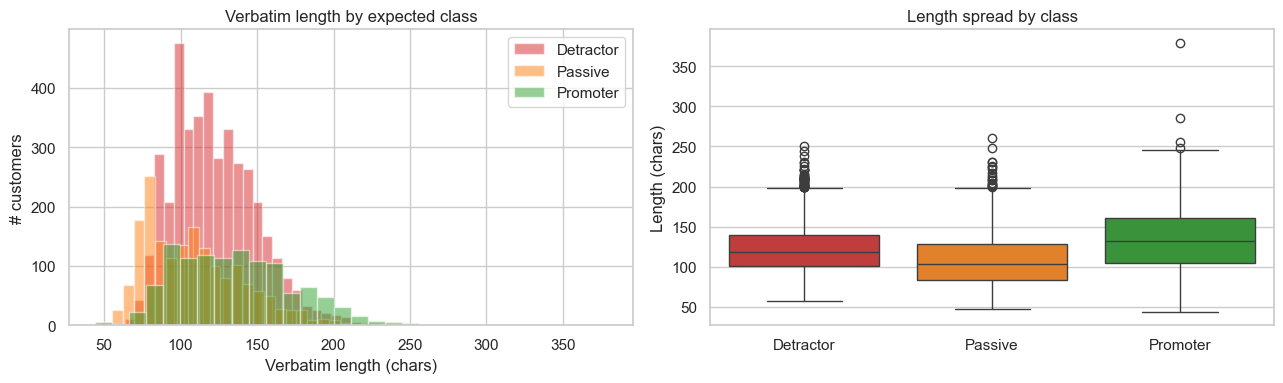

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
df_clean = df.dropna(subset=["verbatim"]).copy()
df_clean["len"] = df_clean["verbatim"].str.len()

for cls in NPS_CLASSES:
    sub = df_clean[df_clean["expected_class"] == cls]["len"]
    axes[0].hist(sub, bins=30, alpha=0.5, label=cls, color=NPS_PALETTE[cls])
axes[0].set_xlabel("Verbatim length (chars)")
axes[0].set_ylabel("# customers")
axes[0].set_title("Verbatim length by expected class")
axes[0].legend()

# Boxplot
sns.boxplot(
    data=df_clean, x="expected_class", y="len", ax=axes[1],
    hue="expected_class", palette=NPS_PALETTE, order=NPS_CLASSES, legend=False,
)
axes[1].set_title("Length spread by class")
axes[1].set_xlabel("")
axes[1].set_ylabel("Length (chars)")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "25_verbatim_length.png")
plt.show()

## 4. Vocabulary signal — top words per class

In [6]:
import re
from collections import Counter

STOPWORDS = {
    "the", "a", "an", "i", "is", "to", "and", "of", "it", "for", "in", "on",
    "with", "this", "that", "be", "have", "has", "are", "was", "but", "my",
    "me", "you", "your", "we", "our", "they", "their", "as", "at", "by",
    "from", "or", "not", "so", "do", "does", "did", "i'm", "im", "i've",
    "ive", "i'll", "ill", "i'd", "id", "it's", "its", "don't", "dont",
    "doesn't", "doesnt", "won't", "wont", "can", "could", "should", "would",
    "if", "when", "what", "which", "who", "where", "why", "how", "just",
    "really", "very",
}


def top_words(series, n=15, min_len=3):
    counter = Counter()
    for txt in series:
        words = re.findall(r"[A-Za-z']+", txt.lower())
        for w in words:
            if len(w) >= min_len and w not in STOPWORDS:
                counter[w] += 1
    return counter.most_common(n)


for cls in NPS_CLASSES:
    sub = df_clean[df_clean["expected_class"] == cls]["verbatim"]
    print(f"\n--- Top words: {cls} (n={len(sub)}) ---")
    for word, count in top_words(sub, n=12):
        print(f"  {word:<15} ({count})")


--- Top words: Detractor (n=4105) ---
  last            (3563)
  bill            (1626)
  month's         (1584)
  internet        (1549)
  month           (1123)
  disappointed    (1066)
  nobody          (959)
  down            (940)
  way             (926)
  been            (862)
  went            (831)
  still           (810)

--- Top words: Passive (n=1789) ---
  last            (1503)
  bill            (978)
  everything      (946)
  month's         (924)
  bit             (898)
  seems           (833)
  fine            (490)
  high            (420)
  night's         (370)
  service         (342)
  seemed          (324)
  internet        (310)

--- Top words: Promoter (n=1149) ---
  last            (947)
  service         (686)
  month's         (583)
  bill            (502)
  great           (481)
  everything      (354)
  happy           (348)
  been            (342)
  month           (311)
  bit             (286)
  recommend       (284)
  definitely      (263)


## 5. Counter-intuitive cases

These are the ~15 % cases where the verbatim deliberately contradicts the expected class
(noisy training signal, by design — see `src/verbatims/prompts.py`).

In [7]:
if "counter_intuitive" in df.columns:
    ci_count = df["counter_intuitive"].sum()
    print(f"Counter-intuitive cases: {int(ci_count)} ({ci_count / len(df):.1%})")
    
    print("\nSample CI verbatims:")
    ci_samples = df[df["counter_intuitive"] == True].dropna(subset=["verbatim"]).sample(
        min(5, int(ci_count)), random_state=42
    )
    for _, row in ci_samples.iterrows():
        print(f"\n[{row.name}] expected={row['expected_class']}:")
        print(f"  \"{row['verbatim']}\"")
else:
    print("'counter_intuitive' column not found — skipping CI analysis")

Counter-intuitive cases: 1068 (15.2%)

Sample CI verbatims:

[1469-LBJQJ] expected=Passive:
  "The service is great and I love my fiber optic internet, but I wish you could make the billing process a bit smoother."

[5980-NOPLP] expected=Detractor:
  "Last month's bill was a bit higher than usual, and I noticed there were no notifications about it. Hope that gets fixed soon."

[3936-QQFLL] expected=Passive:
  "Last night's outage was really frustrating, but I appreciate how quickly you guys fixed it this morning."

[5834-ASPWA] expected=Detractor:
  "Last night's service outage was frustrating. I understand it happens sometimes, but I was hoping for better reliability with my new plan."

[5339-TJFEK] expected=Passive:
  "The service has been great overall, but I'm really upset about those unexpected data overage fees. Can you help me get that sorted out?"


## 6. Synthèse Phase 5

### Ce qui a été produit
- 7 043 verbatims synthétiques générés sur Colab GPU avec Qwen2.5-7B-Instruct
- ~15 % de cas counter-intuitifs (bruit réaliste, brief Section 4.4)
- Audit de qualité : longueur, mots interdits, doublons
- Vocabulaire différencié par classe (signal exploitable Phase 8)

### Reproductibilité
- Prompts construits déterministiquement depuis le dataset (seed=42)
- Génération avec `torch.manual_seed(42)`
- Le notebook Colab est reproductible : même prompts file → mêmes verbatims

### Prochaine étape

**Option A — Phase 6 (baselines)** : commencer la modélisation tabulaire pure.
**Option B — Phase 8 (hybride)** : si Phase 6 déjà faite, intégrer les verbatims via embeddings.

Recommandation : faire Phase 6 d'abord (baseline tabulaire de référence), puis Phase 8 pour quantifier le gain du texte.